In [4]:
import heapq
import time
from collections import deque

# The shared Network Graph
network_graph = {
    'Workstation_Entry': {'Firewall_Main': 2, 'Router_1': 5},
    'Firewall_Main': {'Web_Server': 3, 'DMZ_Switch': 4},
    'Router_1': {'HR_PC': 2, 'Finance_Server': 6},
    'Web_Server': {'App_Server': 4},
    'DMZ_Switch': {'App_Server': 2, 'Backup_Controller': 5},
    'HR_PC': {'Finance_Server': 1},
    'Finance_Server': {'Secure_Database': 7},
    'App_Server': {'Secure_Database': 3},
    'Backup_Controller': {'Secure_Database': 2},
    'Secure_Database': {}
}

# The shared Heuristic values for A* and Hill Climbing
heuristic = {
    'Workstation_Entry': 9, 'Firewall_Main': 7, 'Router_1': 8,
    'Web_Server': 4, 'DMZ_Switch': 5, 'HR_PC': 6,
    'Finance_Server': 5, 'App_Server': 2, 'Backup_Controller': 2,
    'Secure_Database': 0
}

1. Breadth-First Search (BFS) Code
BFS explores layer by layer using a FIFO (First-In, First-Out) queue. It ignores weights completely.

In [5]:
def bfs(graph, start, goal):
    start_time = time.time()
    queue = deque([[start]])
    visited = set()
    nodes_expanded = 0

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            # Calculate total cost of this discovered path
            total_cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
            exec_time = (time.time() - start_time) * 1000
            return path, total_cost, nodes_expanded, exec_time

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
    return None, 0, nodes_expanded, 0

# Test BFS
path, cost, expanded, t = bfs(network_graph, 'Workstation_Entry', 'Secure_Database')
print(f"BFS Path: {path}\nCost: {cost}\nNodes Expanded: {expanded}\nTime: {t:.4f} ms")

BFS Path: ['Workstation_Entry', 'Router_1', 'Finance_Server', 'Secure_Database']
Cost: 18
Nodes Expanded: 9
Time: 0.0234 ms


In [6]:
def ucs(graph, start, goal):
    start_time = time.time()
    # priority queue stores tuples: (cumulative_cost, [current_path])
    pq = [(0, [start])]
    visited = set()
    nodes_expanded = 0

    while pq:
        cost, path = heapq.heappop(pq)
        node = path[-1]

        if node == goal:
            exec_time = (time.time() - start_time) * 1000
            return path, cost, nodes_expanded, exec_time

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor, edge_cost in graph[node].items():
                if neighbor not in visited:
                    new_path = list(path)
                    new_path.append(neighbor)
                    heapq.heappush(pq, (cost + edge_cost, new_path))
    return None, 0, nodes_expanded, 0

# Test UCS
path, cost, expanded, t = ucs(network_graph, 'Workstation_Entry', 'Secure_Database')
print(f"UCS Path: {path}\nCost: {cost}\nNodes Expanded: {expanded}\nTime: {t:.4f} ms")

UCS Path: ['Workstation_Entry', 'Firewall_Main', 'DMZ_Switch', 'App_Server', 'Secure_Database']
Cost: 11
Nodes Expanded: 8
Time: 0.0362 ms


 DFS and A* Search algorithms

In [7]:
def dfs(graph, start, goal):
    start_time = time.time()
    stack = [[start]]
    visited = set()
    nodes_expanded = 0

    while stack:
        path = stack.pop()  # Pops the last added element (LIFO)
        node = path[-1]

        if node == goal:
            total_cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
            exec_time = (time.time() - start_time) * 1000
            return path, total_cost, nodes_expanded, exec_time

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor in graph[node]:
                if neighbor not in visited:
                    new_path = list(path)
                    new_path.append(neighbor)
                    stack.append(new_path)
    return None, 0, nodes_expanded, 0

# Test DFS
path, cost, expanded, t = dfs(network_graph, 'Workstation_Entry', 'Secure_Database')
print(f"DFS Path: {path}\nCost: {cost}\nNodes Expanded: {expanded}\nTime: {t:.4f} ms")

DFS Path: ['Workstation_Entry', 'Router_1', 'Finance_Server', 'Secure_Database']
Cost: 18
Nodes Expanded: 3
Time: 0.0207 ms


2. A* Search CodeNotice how the structure below looks exactly like Partner 1's UCS code! The only difference is when pushing to the priority queue, we sort by f(n) = cost + heuristic[neighbor]

In [8]:
def a_star(graph, start, goal, h_dict):
    start_time = time.time()
    # priority queue stores: (f(n), cumulative_g(n), [current_path])
    pq = [(h_dict[start], 0, [start])]
    visited = set()
    nodes_expanded = 0

    while pq:
        _, g_cost, path = heapq.heappop(pq)
        node = path[-1]

        if node == goal:
            exec_time = (time.time() - start_time) * 1000
            return path, g_cost, nodes_expanded, exec_time

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor, edge_cost in graph[node].items():
                if neighbor not in visited:
                    new_path = list(path)
                    new_path.append(neighbor)
                    new_g = g_cost + edge_cost
                    new_f = new_g + h_dict[neighbor]
                    heapq.heappush(pq, (new_f, new_g, new_path))
    return None, 0, nodes_expanded, 0

# Test A*
path, cost, expanded, t = a_star(network_graph, 'Workstation_Entry', 'Secure_Database', heuristic)
print(f"A* Path: {path}\nCost: {cost}\nNodes Expanded: {expanded}\nTime: {t:.4f} ms")

A* Path: ['Workstation_Entry', 'Firewall_Main', 'DMZ_Switch', 'App_Server', 'Secure_Database']
Cost: 11
Nodes Expanded: 5
Time: 0.0207 ms


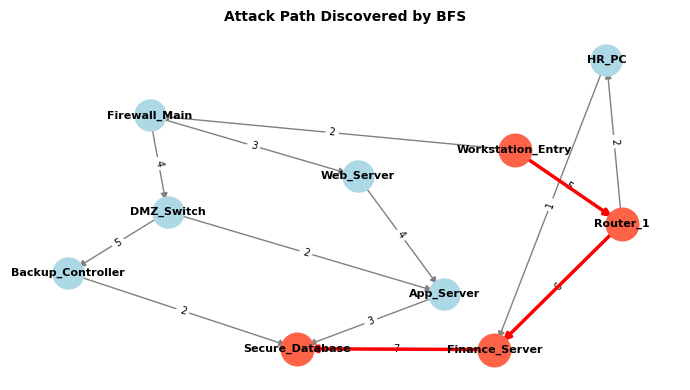

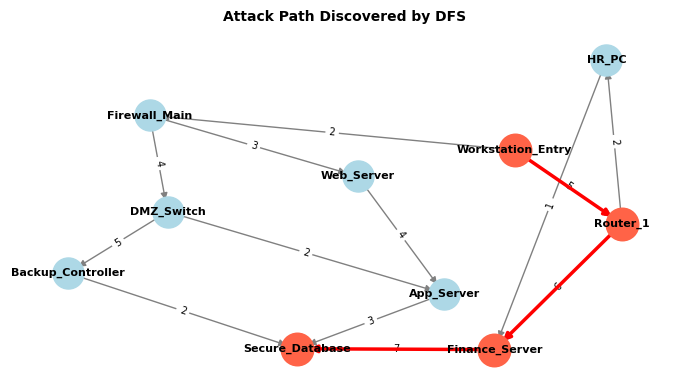

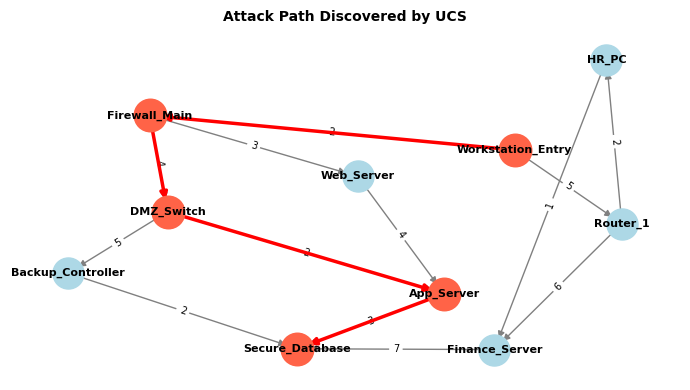

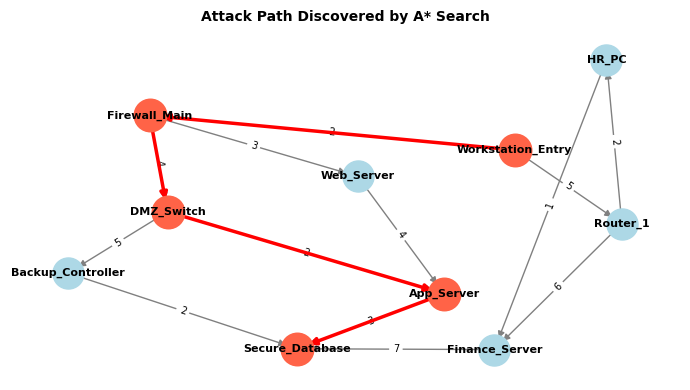

In [10]:
# 1. Run and display BFS
bfs_path, _, _, _ = bfs(network_graph, 'Workstation_Entry', 'Secure_Database')
draw_network_path(network_graph, path=bfs_path, title="Attack Path Discovered by BFS")

# 2. Run and display DFS
dfs_path, _, _, _ = dfs(network_graph, 'Workstation_Entry', 'Secure_Database')
draw_network_path(network_graph, path=dfs_path, title="Attack Path Discovered by DFS")

# 3. Run and display UCS
ucs_path, _, _, _ = ucs(network_graph, 'Workstation_Entry', 'Secure_Database')
draw_network_path(network_graph, path=ucs_path, title="Attack Path Discovered by UCS")

# 4. Run and display A*
a_path, _, _, _ = a_star(network_graph, 'Workstation_Entry', 'Secure_Database', heuristic)
draw_network_path(network_graph, path=a_path, title="Attack Path Discovered by A* Search")

HILL CLIMBING
the attacker starts at H_Entry and wants to reach H_Goal. From H_Entry, the choices are Node_A (heuristic 4) or Node_B (heuristic 5). The algorithm greedily chooses Node_A because 4 is lower (better) than 5. However, Node_A is a dead-end with no path to the goal! Since all its neighbors have worse or non-existent scores, Hill Climbing gets trapped in a local maximum and fails.

Hill Climbing Path: ['H_Entry', 'Node_A']
Result/Cost: FAILED (Trapped at Local Maximum)
Nodes Expanded: 1


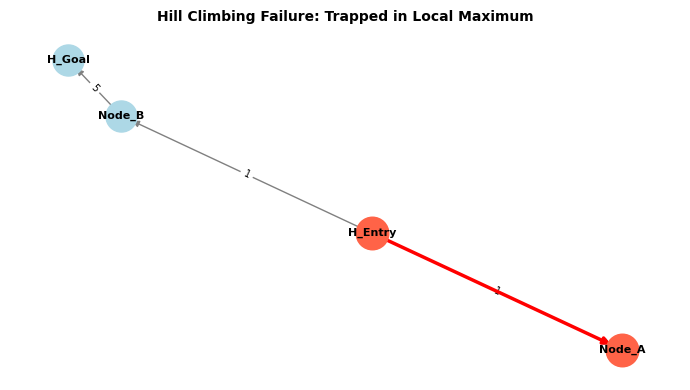

In [11]:
# Separate small network to demonstrate Hill Climbing Failure Case
import time
hill_climbing_graph = {
    'H_Entry': {'Node_A': 1, 'Node_B': 1},
    'Node_A': {},      # Dead end! Trapped here.
    'Node_B': {'H_Goal': 5},
    'H_Goal': {}
}

hc_heuristic = {
    'H_Entry': 6,
    'Node_A': 4,       # Looks closer to goal greedily, but is a trap!
    'Node_B': 5,       # Actually leads to the goal, but has a worse heuristic initially
    'H_Goal': 0
}

def hill_climbing(graph, start, goal, h_dict):
    start_time = time.time()
    current_node = start
    path = [current_node]
    nodes_expanded = 0

    while current_node != goal:
        neighbors = list(graph[current_node].keys())
        if not neighbors:
            # Trapped at a local maximum (dead end)
            exec_time = (time.time() - start_time) * 1000
            return path, "FAILED (Trapped at Local Maximum)", nodes_expanded, exec_time

        nodes_expanded += 1
        # Find the neighbor with the best (lowest) heuristic value
        best_neighbor = min(neighbors, key=lambda n: h_dict.get(n, float('inf')))

        # If the best neighbor doesn't improve the heuristic, we stop
        if h_dict[best_neighbor] >= h_dict[current_node]:
            exec_time = (time.time() - start_time) * 1000
            return path, "FAILED (No better neighbor)", nodes_expanded, exec_time

        current_node = best_neighbor
        path.append(current_node)

    exec_time = (time.time() - start_time) * 1000
    total_cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
    return path, total_cost, nodes_expanded, exec_time

# Test and Visualize Hill Climbing Failure Case
hc_path, hc_cost, hc_expanded, hc_time = hill_climbing(hill_climbing_graph, 'H_Entry', 'H_Goal', hc_heuristic)
print(f"Hill Climbing Path: {hc_path}\nResult/Cost: {hc_cost}\nNodes Expanded: {hc_expanded}")

# Generate Figure for Hill Climbing Failure Case
draw_network_path(hill_climbing_graph, path=hc_path, title="Hill Climbing Failure: Trapped in Local Maximum")

Minimax with Alpha-Beta Pruning (Adversarial Search)
Level 0: Attacker (Max) chooses an entry strategy (Choice_1 or Choice_2).

Level 1: Defender (Min) counters by applying security patches, leading to leaf node outcomes (threat values 3, 5, 2, 9).

In [13]:
# A static representation of a 3-level Deep Security Threat Decision Tree
# Index 0 and 1 are paths under Choice_1; Index 2 and 3 are paths under Choice_2
leaf_threat_values = [3, 5, 2, 9]

class AdversarialSimulation:
    def __init__(self):
        self.nodes_expanded = 0
        self.prune_count = 0

    def minimax_standard(self, depth, node_index, is_maximizing):
        self.nodes_expanded += 1
        # Leaf nodes (Depth 2)
        if depth == 2:
            return leaf_threat_values[node_index]

        if is_maximizing:
            max_eval = float('-inf')
            for i in range(2):
                eval_val = self.minimax_standard(depth + 1, node_index * 2 + i, False)
                max_eval = max(max_eval, eval_val)
            return max_eval
        else:
            min_eval = float('inf')
            for i in range(2):
                eval_val = self.minimax_standard(depth + 1, node_index * 2 + i, True)
                min_eval = min(min_eval, eval_val)
            return min_eval

    def minimax_alpha_beta(self, depth, node_index, is_maximizing, alpha, beta):
        self.nodes_expanded += 1
        if depth == 2:
            return leaf_threat_values[node_index]

        if is_maximizing:
            max_eval = float('-inf')
            for i in range(2):
                eval_val = self.minimax_alpha_beta(depth + 1, node_index * 2 + i, False, alpha, beta)
                max_eval = max(max_eval, eval_val)
                alpha = max(alpha, eval_val)
                if beta <= alpha:
                    self.prune_count += 1
                    break # Prune branch
            return max_eval
        else:
            min_eval = float('inf')
            for i in range(2):
                eval_val = self.minimax_alpha_beta(depth + 1, node_index * 2 + i, True, alpha, beta)
                min_eval = min(min_eval, eval_val)
                beta = min(beta, eval_val)
                if beta <= alpha:
                    self.prune_count += 1
                    break # Prune branch
            return min_eval

# Run both simulations to demonstrate performance gains
sim1 = AdversarialSimulation()
start_t = time.time()
best_score_std = sim1.minimax_standard(0, 0, True)
t_std = (time.time() - start_t) * 1000
nodes_std = sim1.nodes_expanded

sim2 = AdversarialSimulation()
start_t = time.time()
best_score_ab = sim2.minimax_alpha_beta(0, 0, True, float('-inf'), float('inf'))
t_ab = (time.time() - start_t) * 1000
nodes_ab = sim2.nodes_expanded
pruned_branches = sim2.prune_count

print(f"Standard Minimax -> Best Threat Score: {best_score_std}, Nodes Checked: {nodes_std}, Time: {t_std:.4f}ms")
print(f"Alpha-Beta Pruning -> Best Threat Score: {best_score_ab}, Nodes Checked: {nodes_ab}, Pruned Branches: {pruned_branches}, Time: {t_ab:.4f}ms")

Standard Minimax -> Best Threat Score: 3, Nodes Checked: 7, Time: 0.0889ms
Alpha-Beta Pruning -> Best Threat Score: 3, Nodes Checked: 6, Pruned Branches: 1, Time: 0.1180ms


Visualizing the Adversarial Decision Tree

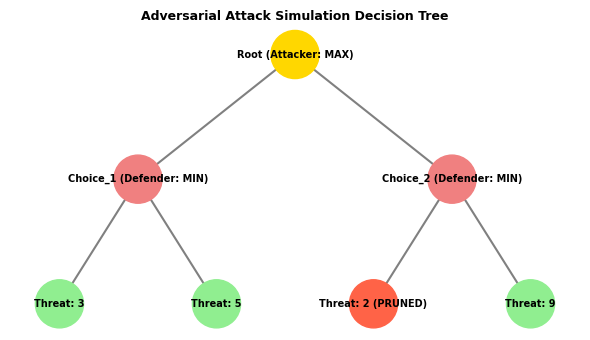

In [14]:
def draw_adversarial_tree():
    G = nx.Graph()
    # Define parent-child tree links
    edges = [
        ('Root (Attacker: MAX)', 'Choice_1 (Defender: MIN)'),
        ('Root (Attacker: MAX)', 'Choice_2 (Defender: MIN)'),
        ('Choice_1 (Defender: MIN)', 'Threat: 3'),
        ('Choice_1 (Defender: MIN)', 'Threat: 5'),
        ('Choice_2 (Defender: MIN)', 'Threat: 2 (PRUNED)'),
        ('Choice_2 (Defender: MIN)', 'Threat: 9')
    ]
    G.add_edges_from(edges)

    # Static visual layout coordinates for a clean tree representation
    pos = {
        'Root (Attacker: MAX)': (0, 2),
        'Choice_1 (Defender: MIN)': (-1, 1),
        'Choice_2 (Defender: MIN)': (1, 1),
        'Threat: 3': (-1.5, 0),
        'Threat: 5': (-0.5, 0),
        'Threat: 2 (PRUNED)': (0.5, 0),
        'Threat: 9': (1.5, 0)
    }

    plt.figure(figsize=(6, 3.5))
    node_colors = ['gold' if 'Root' in n else 'lightcoral' if 'MIN' in n else 'tomato' if 'PRUNED' in n else 'lightgreen' for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5)

    plt.title("Adversarial Attack Simulation Decision Tree", fontsize=9, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_adversarial_tree()

In [15]:
import pandas as pd

# 1. Run the pathfinding algorithms to gather real-time data
bfs_p, bfs_c, bfs_e, bfs_t = bfs(network_graph, 'Workstation_Entry', 'Secure_Database')
dfs_p, dfs_c, dfs_e, dfs_t = dfs(network_graph, 'Workstation_Entry', 'Secure_Database')
ucs_p, ucs_c, ucs_e, ucs_t = ucs(network_graph, 'Workstation_Entry', 'Secure_Database')
a_p, a_c, a_e, a_t = a_star(network_graph, 'Workstation_Entry', 'Secure_Database', heuristic)

# 2. Structure the data for the final comparison matrix
table_data = {
    "Algorithm": [
        "Breadth-First Search (BFS)",
        "Depth-First Search (DFS)",
        "Uniform Cost Search (UCS)",
        "A* Search Algorithm",
        "Hill Climbing (Local)",
        "Minimax (Standard)",
        "Alpha-Beta Pruning"
    ],
    "Discovered Path": [
        " -> ".join(bfs_p),
        " -> ".join(dfs_p),
        " -> ".join(ucs_p),
        " -> ".join(a_p),
        " -> ".join(hc_path),
        "Threat Decision Evaluation",
        "Threat Decision Evaluation"
    ],
    "Total Cost": [bfs_c, dfs_c, ucs_c, a_c, hc_cost, "N/A", "N/A"],
    "Nodes Expanded": [bfs_e, dfs_e, ucs_e, a_e, hc_expanded, nodes_std, nodes_ab],
    "Execution Time (ms)": [
        f"{bfs_t:.3f}",
        f"{dfs_t:.3f}",
        f"{ucs_t:.3f}",
        f"{a_t:.3f}",
        f"{hc_time:.3f}",
        f"{t_std:.3f}",
        f"{t_ab:.3f}"
    ]
}

# 3. Create and display the Pandas DataFrame
comparison_df = pd.DataFrame(table_data)
comparison_df

,Algorithm,Discovered Path,Total Cost,Nodes Expanded,Execution Time (ms)
0,Breadth-First Search (BFS),Workstation_Entry -> Router_1 -> Finance_Serve...,18,9,0.033
1,Depth-First Search (DFS),Workstation_Entry -> Router_1 -> Finance_Serve...,18,3,0.010
2,Uniform Cost Search (UCS),Workstation_Entry -> Firewall_Main -> DMZ_Swit...,11,8,0.026
3,A* Search Algorithm,Workstation_Entry -> Firewall_Main -> DMZ_Swit...,11,5,0.015
4,Hill Climbing (Local),H_Entry -> Node_A,FAILED (Trapped at Local Maximum),1,0.013
5,Minimax (Standard),Threat Decision Evaluation,N/A,7,0.089
6,Alpha-Beta Pruning,Threat Decision Evaluation,N/A,6,0.118
